### Quickstart : Compare runs, choose a model, and deploy it to a REST API

In this quickstart, we will:
* Run a hyperparameter sweep on a training script.
* Compare the results of the runs in the MLflow UI.
* Choose the best run and register it as a model.
* Deploy the model to a REST API.
* Build a container image suitable for deployment to a cloud platform.

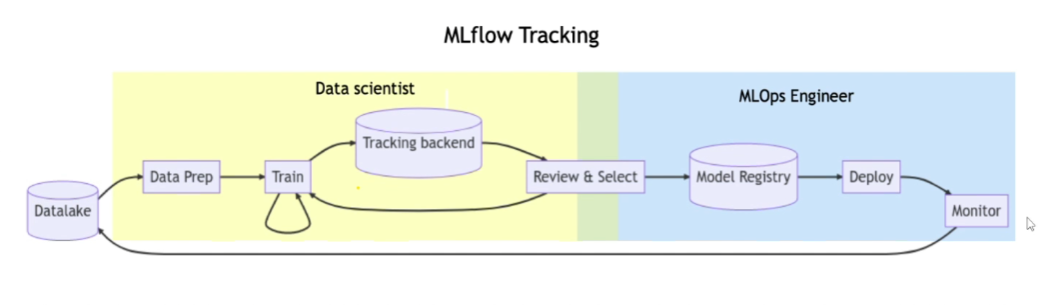

In [3]:
import keras
import numpy as np
import pandas as pd
import tensorflow as tf
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import mlflow
from mlflow.models import infer_signature

In [10]:
#Loading the dataset
data = pd.read_csv('https://raw.githubusercontent.com/mlflow/mlflow/master/tests/datasets/winequality-white.csv',
                   sep=';')
                   

data.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [17]:
#Splitting the dataset into training and testing
train, test = train_test_split(data, test_size=0.25, random_state=42)

train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
2835,6.3,0.25,0.22,3.30,0.048,41.0,161.0,0.99256,3.16,0.50,10.5,6
1157,7.8,0.30,0.29,16.85,0.054,23.0,135.0,0.99980,3.16,0.38,9.0,6
744,7.4,0.38,0.27,7.50,0.041,24.0,160.0,0.99535,3.17,0.43,10.0,5
1448,7.4,0.16,0.49,1.20,0.055,18.0,150.0,0.99170,3.23,0.47,11.2,6
3338,7.2,0.27,0.28,15.20,0.046,6.0,41.0,0.99665,3.17,0.39,10.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4426,6.2,0.21,0.52,6.50,0.047,28.0,123.0,0.99418,3.22,0.49,9.9,6
466,7.0,0.14,0.32,9.00,0.039,54.0,141.0,0.99560,3.22,0.43,9.4,6
3092,7.6,0.27,0.52,3.20,0.043,28.0,152.0,0.99129,3.02,0.53,11.4,6
3772,6.3,0.24,0.29,13.70,0.035,53.0,134.0,0.99567,3.17,0.38,10.6,6


In [23]:
x_train = train.drop(columns='quality', axis=1).values
y_train = train['quality'].values.ravel()  #"ravel()" is used to convert the 2D array to 1D array

#Test set
x_test = test.drop(columns='quality', axis=1).values
y_test = test['quality'].values.ravel()

#Splitting the training set into training and validation set
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.20, random_state=42)

In [24]:
signature = infer_signature(x_train, y_train)

In [40]:
#Creating ANN Model
def train_model(params, epochs, x_train, y_train, x_val, y_val, x_test, y_test):

    #Defining the model architecture
    mean = np.mean(x_train, axis=0)  #We will use this for normalization later
    var = np.var(x_train, axis=0)

    model = keras.Sequential(
        [
            keras.Input([x_train.shape[1]]),
            keras.layers.Normalization(mean = mean, variance = var),
            keras.layers.Dense(64, activation='relu'),
            keras.layers.Dense(1)
    ]
       )

    #Compiling the model
    model.compile(optimizer = keras.optimizers.SGD(learning_rate = params["lr"], momentum = params["momentum"]),
                  loss = "mean_squared_error", 
                  metrics = [keras.metrics.RootMeanSquaredError()])
    
    #Training the ANN model with "lr" and "momentum" as hyperparameters and track each of them
    with mlflow.start_run(nested = True):
        model.fit(x_train, y_train, validation_data = (x_val, y_val), epochs = epochs, 
                    batch_size = 64)
        
        #Evaluating the model
        eval_result = model.evaluate(x_val, y_val, batch_size = 64)
        eval_rmse = eval_result[1]

        #Logging the parameters and results
        mlflow.log_params(params)
        mlflow.log_metric("eval_rmse", eval_rmse)

        #Logging the model
        mlflow.tensorflow.log_model(model, "model", signature=signature)  #Here we can use "mlflow.sklearn.log_model()" as well but since it is an ANN model we are using tensorflow

        return {"loss" : eval_rmse, "status" : STATUS_OK, "model" : model}


In [41]:
def objective(params):
    result = train_model(
        params, 
        epochs = 3,
        x_train = x_train,
        y_train = y_train,
        x_val = x_val,
        y_val = y_val,
        x_test = x_test,
        y_test = y_test
    )
    return result

In [ ]:
space = {
    "lr" : hp.loguniform("lr", np.log(1e-5), np.log(1e-1)),
    #This defines the search space for the learning rate (lr)
    #"hp.loguniform" samples values from a log-uniform distribution between log(1e-5) and log(1e-1)
    #This ensures that values are spread exponentially rather than linearly, 
    #which is useful when tuning the learning rate since small changes can have a large impact
    #The actual sampled values will be exponentiated (exp(sampled_value)) to fall within the range [1e-5, 1e-1]

    "momentum" : hp.uniform("momentum", 0.0, 1.0)
    #This defines the search space for the momentum hyperparameter
    #"hp.uniform" samples values from a uniform distribution between 0.0 and 1.0, 
    #meaning all values in this range have equal probability
}

#This space dictionary is typically used in Bayesian optimization or 
#random search using hyperopt.fmin() to optimize hyperparameters for a machine learning model

In [ ]:
mlflow.set_experiment("/wine-quality")

with mlflow.start_run():
    #Conducting the hyperparameter search using Hyperopt
    trials = Trials()
    best = fmin(
        fn = objective,
        space = space,
        algo = tpe.suggest,
        max_evals = 4,
        trials = trials
    )

    #Fetch details of the best run
    best_run = sorted(trials.results, key = lambda x : x["loss"])[0]
    #This line of code is extracting the best hyperparameter configuration from the results of a hyperopt optimization process
    #"trials" is an instance of hyperopt.Trials(), which stores all the results of the optimization process.
    #trials.results is a list of dictionaries, where each dictionary contains information about a trial (iteration), including the loss value and other metrics.
    #"sorted(trials.results, key=lambda x: x["loss"])", This sorts the list of results in ascending order based on the "loss" key (since hyperopt minimizes the loss function).
    #The lower the loss, the better the hyperparameter configuration.
    #"sorted(...)[0]", This selects the first element from the sorted list, which corresponds to the trial with the lowest loss (i.e., the best run).
    #The best_run variable will contain the results of the best hyperparameter configuration found during the optimization process.
    #This can be used to extract the optimal learning rate (lr) and momentum (momentum) values.

    #Logging the best parameters, loss and model
    mlflow.log_params(best)
    mlflow.log_metric("eval_rmse", best_run["loss"])
    mlflow.tensorflow.log_model(best_run["model"], "model", signature=signature)

    #Print the best parameters and corresponding loss
    print(f"Best parameters: {best}")
    print(f"Best eval rmse: {best_run['loss']}") 

Epoch 1/3                                            

 1/46 ━━━━━━━━━━━━━━━━━━━━ 19s 442ms/step - loss: 37.1865 - root_mean_squared_error: 6.0981
25/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.6032 - root_mean_squared_error: 3.8167   
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.2342 - root_mean_squared_error: 3.1866
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 10.9615 - root_mean_squared_error: 3.1445 - val_loss: 1.4960 - val_root_mean_squared_error: 1.2231

Epoch 2/3                                            

 1/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 1.3150 - root_mean_squared_error: 1.1467
31/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3770 - root_mean_squared_error: 1.1729 
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3402 - root_mean_squared_error: 1.1570 - val_loss: 1.1072 - val_root_mean_squared_error: 1.0522

Epoch 3/3                                            

 1/46 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.9986 - root_mean_squared_error: 0.9993
30

In [45]:
import mlflow

model_uri = 'runs:/b7e32d28fba04c91899c6db16fa65e74/model'

# Replace INPUT_EXAMPLE with your own input example to the model
# A valid input example is a data instance suitable for pyfunc prediction
input_data = x_test

# Verify the model with the provided input data using the logged dependencies.
# For more details, refer to:
# https://mlflow.org/docs/latest/models.html#validate-models-before-deployment
mlflow.models.predict(
    model_uri=model_uri,
    input_data=input_data,
    env_manager="local",
)

2025/02/07 15:14:56 INFO mlflow.models.python_api: It is highly recommended to use `uv` as the environment manager for predicting with MLflow models as its performance is significantly better than other environment managers. Run `pip install uv` to install uv. See https://docs.astral.sh/uv/getting-started/installation for other installation methods.
c:\Users\Tough\anaconda3\envs\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025/02/07 15:14:56 INFO mlflow.models.flavor_backend_registry: Selected backend for flavor 'python_function'


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
{"predictions": [[6.276252746582031], [6.739205360412598], [6.51099967956543], [5.871574878692627], [6.250356674194336], [6.60432243347168], [5.575593948364258], [5.272422790527344], [5.951976776123047], [5.354592323303223], [6.253726959228516], [5.081056594848633], [6.50462532043457], [5.2671003341674805], [7.456230163574219], [5.5836944580078125], [6.546635627746582], [5.836026191711426], [6.090428352355957], [5.407793998718262], [5.374016761779785], [5.911545753479004], [5.5208587646484375], [5.970528602600098], [5.916388511657715], [5.589659690856934], [5.579912185668945], [6.242544174194336], [6.055596351623535], [5.4661712646484375], [5.559690475463867], [5.9027204513549805], [5.769928932189941], [5.399425506591797], [5.776874542236328], [6.454947471618652], [6.3038330078125], [5.283725261688232], [5.563133239746094], [5.554534912109375], [5.787472724914551], [5.701075553894043], [5.939350128173828], [5.638616561889648], [5.219782829284668],

In [46]:
#Loading the model as a Pyfunc model
model_uri = 'runs:/b7e32d28fba04c91899c6db16fa65e74/model'

loaded_model = mlflow.pyfunc.load_model(model_uri)

#Predict on a pandas DataFrame
import pandas as pd
loaded_model.predict(pd.DataFrame(x_test))

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


array([[6.2762527],
       [6.7392054],
       [6.5109997],
       ...,
       [6.0326924],
       [6.7558155],
       [5.8396044]], dtype=float32)

In [47]:
#Register in the model registry
mlflow.register_model(model_uri, "wine-quality-model")

Successfully registered model 'wine-quality-model'.
Created version '1' of model 'wine-quality-model'.


<ModelVersion: aliases=[], creation_timestamp=1738921727259, current_stage='None', description=None, last_updated_timestamp=1738921727259, name='wine-quality-model', run_id='b7e32d28fba04c91899c6db16fa65e74', run_link=None, source='file:///c:/Users/Tough/OneDrive/Desktop/Tough/MLOPS/ML_Flow/My_Class_Workings/3.%20DLMLflow/mlruns/791601733147011685/b7e32d28fba04c91899c6db16fa65e74/artifacts/model', status='READY', status_message=None, tags={}, user_id=None, version=1>